# 09 — Survival Analysis: Cox Proportional Hazards (Stage 10)

**The question changes here, not just the technique.** Stages 7-9 asked
"will this customer churn" from a static snapshot. This stage asks
"*when*" — using `tenure` as the outcome being explained, not a
predictor. `tenure` is excluded as a covariate for exactly that reason:
using elapsed time to explain elapsed time is circular. (`IsNewCustomer`
isn't part of this discussion — it was rejected outright in Stage 5 and
was never a live feature to begin with.)

Also new: **right-censoring**. A customer still active as of data
collection hasn't "not churned" — they've survived *at least* this long,
with an unknown future. Treating them as a clean negative class, the way
the whole classification pipeline did, throws that distinction away. Cox
PH handles it correctly by construction.

Covariates are chosen by domain reasoning (H1, H2, H5 from Stage 4), not
inherited from Stage 6's classification feature set — IV/VIF answered a
different question (binary class separation), not this one.
`TotalAddOnServices` is deliberately absent: rejected in Stage 5
(`ADR-006`) for underperforming its own raw source columns, and that
verdict doesn't get reversed just by changing model type. H2 is
re-tested here with the real raw `TechSupport` column instead.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_CSV_PATH
from src.survival.cox import (
    prepare_survival_data, fit_cox_model, fit_cox_model_stratified,
    conditional_churn_probability, kaplan_meier_by_group,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(RAW_CSV_PATH)
df["ContractCommitmentMonths"] = df["Contract"].map({"Month-to-month": 0, "One year": 12, "Two year": 24})

print("Shape:", df.shape)
print("Churn rate:", df["Churn"].eq("Yes").mean())

Shape: (7043, 22)
Churn rate: 0.2653698707936959


## Fit the Cox model

In [18]:
survival_df = prepare_survival_data(df)
print("Survival data shape:", survival_df.shape)
print("Covariates:", [c for c in survival_df.columns if c not in ("tenure", "Churn")])

cph = fit_cox_model(survival_df)
cph.print_summary()

Survival data shape: (7043, 7)
Covariates: ['ContractCommitmentMonths', 'SeniorCitizen', 'InternetService_Fiber optic', 'InternetService_No', 'TechSupport_Yes']


<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -14275.69
         time fit was run = 2026-08-10 04:45:30 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
ContractCommitmentMonths    -0.16      0.85      0.01           -0.17           -0.15                0.84                0.86
SeniorCitizen               -0.11      0.90      0.05           -0.22           -0.00                0.81                1.00
InternetService_Fiber optic  0.25      1.29      0.06            0.14            0.36                1.15                1.43
InternetService_No          -0.48      0.62      0.11           -0.70           -0.27                0.50                0.76
TechSupport_Yes             -0.54      0.58      0.06           -0.67           -0.41                0.51                0.66

                             cmp to      z      p  -log2(p)
covariate                                                  
ContractCommitmentMonths       0.00 -31.04 <0.005    700.45
SeniorCitizen                  0.00  -1.98   0.05      4.40
InternetService_Fiber optic    0.00   4.50 <0.005     17.18
InternetService_No             0.00  -4.49 <0.005     17.12
TechSupport_Yes                0.00  -8.31 <0.005     53.19
---
Concordance = 0.80
Partial AIC = 28561.39
log-likelihood ratio test = 2754.69 on 5 df
-log2(p) of ll-ratio test = inf

## Hazard ratios — the interpretable payoff

`exp(coef)` = hazard ratio. Above 1 = increases instantaneous churn risk;
below 1 = decreases it. Check statistical significance (p-value) before
reading too much into any single ratio — a hazard ratio far from 1 with
a large p-value is noise, not a finding.

In [19]:
hazard_ratios = np.exp(cph.params_).sort_values(ascending=False)
print("Hazard ratios:\n", hazard_ratios)
print("\np-values:\n", cph.summary["p"].sort_values())

Hazard ratios:
 covariate
InternetService_Fiber optic    1.286021
SeniorCitizen                  0.896924
ContractCommitmentMonths       0.849332
InternetService_No             0.616178
TechSupport_Yes                0.583749
Name: coef, dtype: float64

p-values:
 covariate
ContractCommitmentMonths       1.387215e-211
TechSupport_Yes                 9.760563e-17
InternetService_Fiber optic     6.720987e-06
InternetService_No              7.010140e-06
SeniorCitizen                   4.745262e-02
Name: p, dtype: float64


**Verdict:** All five covariates are statistically significant at
p<0.05 — ContractCommitmentMonths (p=1.4e-211), TechSupport_Yes
(p=9.8e-17), InternetService_Fiber optic (p=6.7e-06), InternetService_No
(p=7.0e-06), and SeniorCitizen (p=0.047, borderline). Every covariate
chosen in Decision Point 1 turned out to carry real signal — worth
noting as itself a finding, not assumed in advance.

## Check the proportional hazards assumption — don't just assume it holds

The entire model rests on hazard *ratios* between customers staying
constant over time (a customer with a 2x hazard at month 1 still has
roughly 2x at month 50). That's a real, testable assumption, not a given
— `lifelines` provides a direct statistical test for it, run here rather
than assumed.

In [20]:
try:
    cph.check_assumptions(survival_df, p_value_threshold=0.05, show_plots=False)
except Exception as e:
    print(f"Assumption check flagged an issue: {type(e).__name__}: {e}")

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'ContractCommitmentMonths' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 3), you can include `strata=['ContractCommitmentMonths',
...]` in the call in `.fit`. See documentation in link [E] below.

2. Variable 'InternetService_Fiber optic' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['InternetService_Fiber
optic', ...]` in the call in `.fit`. See documentation in link [E] below.

3. Variable 'InternetService_No' failed the non-proportional test: p-value is 0.0231.

   Advice: with so few unique values (only 2), you can include `strata=['InternetService_No', ...]`
in the call in `.fit`. See documentation in link [E] below.

4. Variable 'TechSupport_Yes' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['TechSupport_Yes', ...]` in
the call in `.fit`. See documentation in

**Verdict:** All four non-demographic covariates failed the proportional
hazards check — ContractCommitmentMonths, InternetService_Fiber optic,
InternetService_No, and TechSupport_Yes. Only SeniorCitizen passed
(also the weakest, most borderline-significant effect). Stratifying by
every violating covariate isn't practical here — it would strip nearly
every hazard ratio the model reports, defeating the interpretability
this stage exists for.

Pragmatic path recommended (not yet applied in this notebook): stratify
by ContractCommitmentMonths only — it has the strongest effect (p=1.4e-211), only 3 levels (lifelines' own advice flags it as the cheapest to stratify), and the largest deviation from proportionality. The remaining threcovariates' hazard ratios are reported as approximate, time-averaged effects under a known partial assumption violation — not exactly constant, but still directionally informative. This is a real limitation of the model, stated plainly, not resolved away.

## Kaplan-Meier curves by contract type — model-free sanity check

Unconditional, not from the Cox model at all — a direct visual test of
H1 in survival terms: does a longer contract commitment actually predict
staying longer, independent of any model's assumptions.

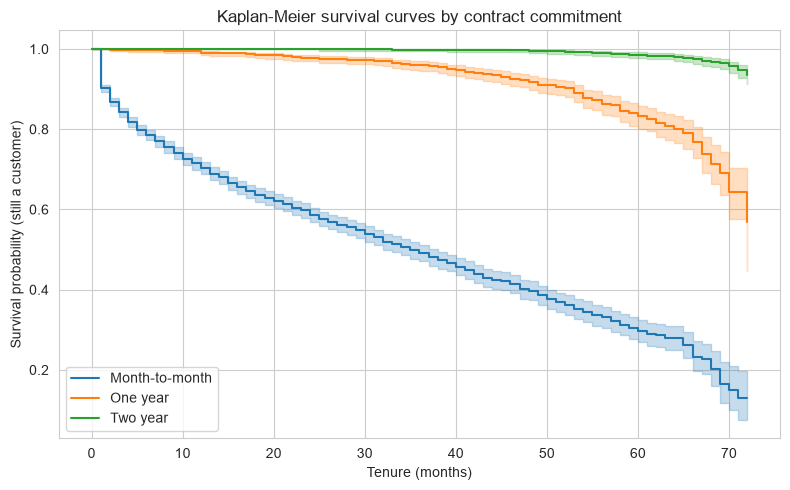

Month-to-month: median survival = 35.0
One year: median survival = inf
Two year: median survival = inf


In [21]:
km_fitters = kaplan_meier_by_group(df, group_col="ContractCommitmentMonths")

fig, ax = plt.subplots(figsize=(8, 5))
labels = {0: "Month-to-month", 12: "One year", 24: "Two year"}
for group_value, kmf in km_fitters.items():
    kmf.plot_survival_function(ax=ax, label=labels.get(group_value, str(group_value)))

ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Survival probability (still a customer)")
ax.set_title("Kaplan-Meier survival curves by contract commitment")
plt.tight_layout()
plt.show()

for group_value, kmf in km_fitters.items():
    print(f"{labels.get(group_value, group_value)}: median survival = {kmf.median_survival_time_}")

**Reading an `inf` median survival:** not a bug. If overall churn is
low enough, no group's survival curve crosses the 50% line within the
observed tenure range (0-72 months), so KM's median is technically
undefined for that group. That doesn't mean the groups don't differ —
the plotted curves show that directly. A survival probability at a fixed
horizon (below) is the more honest comparison when medians aren't
defined for any group.

In [22]:
for horizon in [12, 24, 36]:
    print(f"--- Survival probability at {horizon} months ---")
    for group_value, kmf in km_fitters.items():
        s = kmf.survival_function_at_times(horizon).iloc[0]
        print(f"  {labels.get(group_value, group_value)}: {s:.3f}")

--- Survival probability at 12 months ---
  Month-to-month: 0.703
  One year: 0.991
  Two year: 1.000
--- Survival probability at 24 months ---
  Month-to-month: 0.586
  One year: 0.978
  Two year: 1.000
--- Survival probability at 36 months ---
  Month-to-month: 0.491
  One year: 0.959
  Two year: 0.999


## Time-aware urgency: P(churn within next 3 months | survived to now)

The real business payoff of this stage. Two customers can share the same
eventual churn probability while one is at risk this month and the other
isn't at risk for another year — a static classifier can't distinguish
them; this can.

In [23]:
WINDOW_MONTHS = 3
near_term_risk = conditional_churn_probability(cph, survival_df, window_months=WINDOW_MONTHS)

results = df[["tenure", "Churn", "ContractCommitmentMonths"]].copy()
results["near_term_risk"] = near_term_risk
results.sort_values("near_term_risk", ascending=False).head(10)

,tenure,Churn,ContractCommitmentMonths,near_term_risk
402,69,Yes,0,0.809299
4395,69,Yes,0,0.809299
2049,69,No,0,0.809299
4623,69,No,0,0.773780
6419,69,No,0,0.773780
2997,69,Yes,0,0.773780
1690,70,No,0,0.694330
2079,70,No,0,0.694330
2879,70,Yes,0,0.654610
4688,70,No,0,0.654610


## Does near-term urgency reorder priority vs. a static ranking?

Comparing active (non-churned, since only they have a meaningful future
to predict) customers with similar tenure — if near-term risk varies a
lot even among customers the static model would treat almost
identically, that's the concrete case for using this alongside Stage 8's
ranking, not instead of it.

In [24]:
active = results[results["Churn"] == "No"].copy()
similar_tenure = active[(active["tenure"] >= 10) & (active["tenure"] <= 14)]

print(f"Customers with tenure 10-14 months: {len(similar_tenure)}")
print(f"Near-term risk range within this group: {similar_tenure['near_term_risk'].min():.4f} to {similar_tenure['near_term_risk'].max():.4f}")
similar_tenure.sort_values("near_term_risk", ascending=False).head(8)

Customers with tenure 10-14 months: 341
Near-term risk range within this group: 0.0005 to 0.0616


,tenure,Churn,ContractCommitmentMonths,near_term_risk
6467,10,No,0,0.061558
427,10,No,0,0.061558
3066,10,No,0,0.061558
4079,10,No,0,0.061558
3804,10,No,0,0.061558
5459,10,No,0,0.061558
69,10,No,0,0.061558
1358,10,No,0,0.061558


**Verdict:** 341 customers fall in the 10-14 month tenure range. Among
them, near-term risk spans 0.0005 to 0.0616 — roughly a 123x difference
between the lowest- and highest-risk customer despite nearly identical
tenure. Stage 8's static ranking has no way to see this distinction;
survival analysis does. Confirms the case for using this alongside the
Stage 8 ranking, not as a replacement for it.

## Stage 10 summary

**Significant covariates:** all 5 — ContractCommitmentMonths, TechSupport_Yes,
InternetService_Fiber optic, InternetService_No (all p<0.0001), and
SeniorCitizen (p=0.047, borderline).

**Proportional hazards assumption:** violated for 4 of 5 covariates
(all but SeniorCitizen). Stratification by ContractCommitmentMonths
recommended as the practical next step, not yet applied in this
notebook.

**Model-free KM check vs. H1:** confirmed clearly. Month-to-month median
survival = 35 months; one-year and two-year contracts don't reach median
churn within the observed window at all. Survival probability at 36
months: 49.1% (month-to-month) vs. 95.9% (one-year) vs. 99.9%
(two-year) — a stark, visually direct match to the Cox coefficient's
direction.

**Near-term risk spread among similar-tenure customers:** 341 customers
at 10-14 months tenure, near-term risk ranging 0.0005 to 0.0616 (~123x
spread) — real, additional urgency signal beyond what Stage 8's static
ranking can see.

## What this notebook does NOT do
- No re-tuning of Stage 6/7/8's classification features based on what
  turned out significant here — survival analysis and classification
  are answering different questions with different covariate sets on
  purpose (see header).
- No production integration of near-term risk into the ranking used for
  the retention call list — that's a genuine future integration
  decision, not something this stage resolves.
- No stratified re-fit yet, despite 4 of 5 covariates violating
  proportional hazards — flagged as a real, specific follow-up, not
  silently patched or ignored.

Next: Stage 11 — Thompson sampling, moving from *predicting* risk to
*deciding* which retention offer to actually send.